DISTRIBUTION FITTING

Column: sepal length (cm)
  Best fitting distribution: Gamma
  p-value: 0.2477
  Good fit: Yes

Column: sepal width (cm)
  Best fitting distribution: Gamma
  p-value: 0.1747
  Good fit: Yes

Column: petal length (cm)
  Best fitting distribution: Gamma
  p-value: 0.0000
  Good fit: No

Column: petal width (cm)
  Best fitting distribution: Gamma
  p-value: 0.0002
  Good fit: No

Column: sepal_area
  Best fitting distribution: Gamma
  p-value: 0.9102
  Good fit: Yes

Column: petal_area
  Best fitting distribution: Gamma
  p-value: 0.0000
  Good fit: No


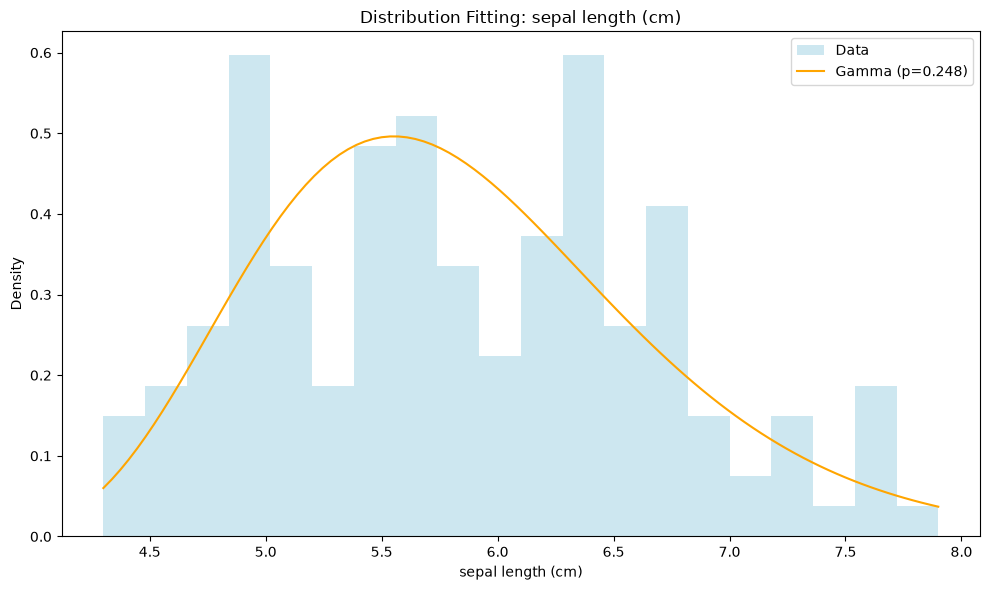

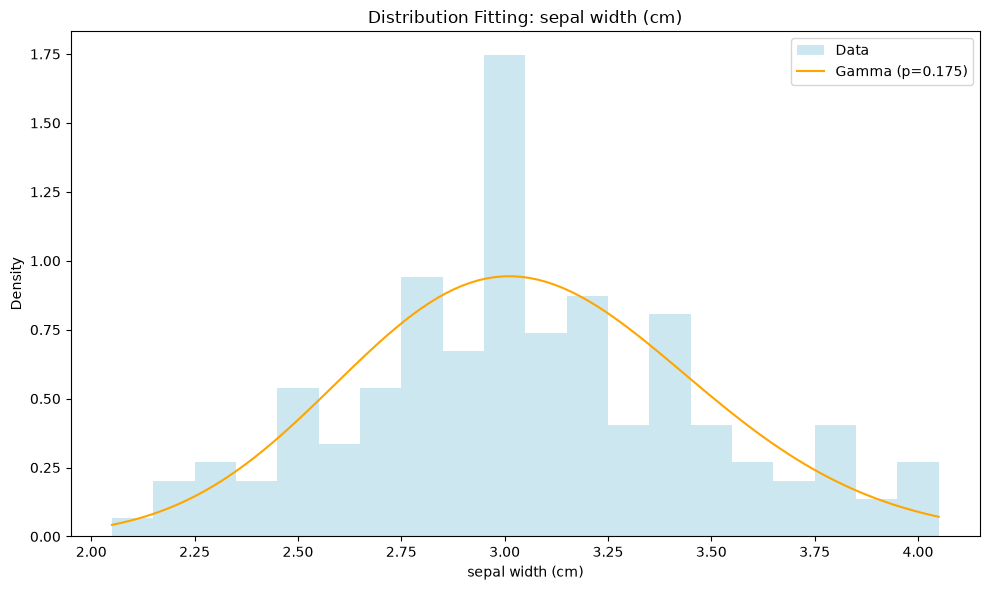

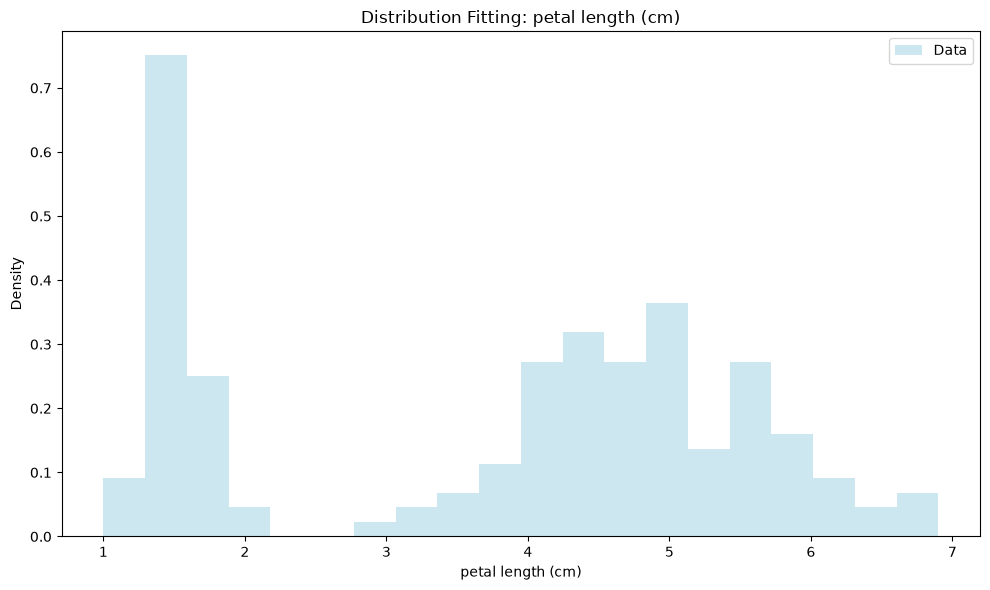


Distribution fitting results saved to 'reports/distribution_fitting_summary.csv'
              column best_fit   p_value  good_fit
0  sepal length (cm)    Gamma  0.247658      True
1   sepal width (cm)    Gamma  0.174734      True
2  petal length (cm)    Gamma  0.000014     False
3   petal width (cm)    Gamma  0.000204     False
4         sepal_area    Gamma  0.910200      True
5         petal_area    Gamma  0.000007     False


In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
from scipy import stats
from src.data_loader import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load cleaned data
loader = DataLoader(data_dir="../data")
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

os.makedirs('../reports/figures', exist_ok=True)

print("=" * 60)
print("DISTRIBUTION FITTING")
print("=" * 60)

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# ==================== 1. FIT DISTRIBUTIONS ====================
def fit_distributions_to_column(data, column_name):
    """Fit multiple distributions to a column of data."""
    results = {}
    distributions = {
        'Normal': stats.norm,
        'Exponential': stats.expon,
        'Gamma': stats.gamma,
        'Lognormal': stats.lognorm,
        'Uniform': stats.uniform
    }
    
    for dist_name, dist in distributions.items():
        try:
            params = dist.fit(data)
            ks_stat, p_value = stats.kstest(data, dist_name.lower(), args=params)
            
            results[dist_name] = {
                'params': params,
                'ks_statistic': ks_stat,
                'p_value': p_value,
                'good_fit': p_value > 0.05
            }
        except Exception as e:
            results[dist_name] = {'error': str(e)}
    
    best_fit = None
    best_p = -1
    for dist_name, result in results.items():
        if 'p_value' in result and result['p_value'] > best_p:
            best_p = result['p_value']
            best_fit = dist_name
    
    return results, best_fit, best_p

# Fit distributions to each numeric column
all_fitting_results = {}

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 10:
        results, best_fit, best_p = fit_distributions_to_column(data, col)
        all_fitting_results[col] = {
            'results': results,
            'best_fit': best_fit,
            'best_p_value': best_p
        }
        
        print(f"\nColumn: {col}")
        print(f"  Best fitting distribution: {best_fit}")
        print(f"  p-value: {best_p:.4f}")
        print(f"  Good fit: {'Yes' if best_p > 0.05 else 'No'}")

# ================= 2. VISUALIZE FITTED DISTRIBUTIONS ==================

def plot_fitted_distributions(df, column, results):
    """Plot histogram with fitted distributions."""
    data = df[column].dropna()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(data, bins=20, density=True, alpha=0.6, color='lightblue', label='Data')
    
    colors = ['red', 'green', 'orange', 'purple', 'brown']
    for idx, (dist_name, result) in enumerate(results.items()):
        if 'params' in result and result['good_fit']:
            dist = getattr(stats, dist_name.lower())
            x = np.linspace(data.min(), data.max(), 100)
            pdf = dist.pdf(x, *result['params'])
            ax.plot(x, pdf, color=colors[idx % len(colors)],
                   label=f"{dist_name} (p={result['p_value']:.3f})")
    
    ax.set_title(f'Distribution Fitting: {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    
    safe_name = column.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'../reports/figures/distribution_fit_{safe_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for the first 3 columns
for col in numeric_cols[:3]:
    if col in all_fitting_results:
        plot_fitted_distributions(df, col, all_fitting_results[col]['results'])

# ================== 3. CREATE DISTRIBUTION SUMMARY ==================

distribution_summary = []
for col, info in all_fitting_results.items():
    distribution_summary.append({
        'column': col,
        'best_fit': info['best_fit'],
        'p_value': info['best_p_value'],
        'good_fit': info['best_p_value'] > 0.05
    })

summary_df = pd.DataFrame(distribution_summary)
summary_df.to_csv('../reports/distribution_fitting_summary.csv', index=False)

print("\nDistribution fitting results saved to 'reports/distribution_fitting_summary.csv'")
print(summary_df.to_string())